# Introduction

This notebook demonstrates how to access and visualize climate model data from the Coupled Model Intercomparison Project Phase 6 (CMIP6) using the intake-esm library.
We will:
- Load the CMIP6 catalog from a modern cloud source.
- Subset a single variable - near-surface air temperature (tas) - from a chosen model.
- Load the dataset efficiently using xarray.
- Visualize global temperature patterns on a map.
- Compute a zonal mean to analyze temperature by latitude.

In [1]:
import intake
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

## Load the CMIP6 Catalog

The Pangeo community provides a cloud-optimized CMIP6 catalog hosted on Google Cloud Storage.
We’ll try that first, then fall back to a smaller NCAR mirror if needed.

In [2]:
for url in [
    "https://cmip6.storage.googleapis.com/pangeo-cmip6.json",  # primary source
    "https://raw.githubusercontent.com/NCAR/intake-esm-datastore/master/catalogs/sample-cmip6.json",  # fallback
]:
    try:
        col = intake.open_esm_datastore(url)
        print(f"✅ Successfully opened catalog from:\n{url}")
        break
    except Exception as e:
        print(f"❌ Failed to open {url}\n   {e}")

col

✅ Successfully opened catalog from:
https://cmip6.storage.googleapis.com/pangeo-cmip6.json


,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,61


## Explore the Catalog

Each CMIP6 dataset is indexed by experiment, variable, and model.
Let’s view the first few entries to understand its structure.

In [3]:
col.df.head(10)

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
5,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,hurs,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
6,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,huss,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
7,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,hus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
8,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,hfss,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
9,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706


## Subset the Dataset

We will focus on:
- Experiment: Historical (past observed climate)
- Variable: tas (near-surface air temperature)
- Model: MPI-ESM1-2-LR
- Frequency: Monthly (Amon)

In [4]:
query = dict(
    experiment_id=['historical'],
    variable_id=['tas'],
    table_id=['Amon'],
    source_id=['MPI-ESM1-2-LR']
)

cat_subset = col.search(**query)
cat_subset.df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r1i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,<NA>,20190710
1,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r10i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,<NA>,20190710
2,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r5i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,<NA>,20190710
3,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r4i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,<NA>,20190710
4,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r2i1p1f1,Amon,tas,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,<NA>,20190710


## Convert to an Xarray.Dataset

We now convert the catalog subset into an actual dataset using to_dataset_dict().
We’ll use robust combination options to handle coordinate mismatches between ensemble members.

In [5]:
ds_dict = cat_subset.to_dataset_dict(
    zarr_kwargs={'consolidated': True},
    storage_options={'token': 'anon'},
    xarray_combine_by_coords_kwargs={
        'join': 'override',          # handle slight misalignment
        'combine_attrs': 'override',
        'coords': 'minimal',
    },
    skip_on_error=True
)

# Extract the first available dataset
ds = list(ds_dict.values())[0]
ds


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


/knight/pixi/sep24/sep25_env-5711917176091715257/envs/default/lib/python3.13/site-packages/intake_esm/source.py:298: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  self._ds = xr.combine_by_coords(
/knight/pixi/sep24/sep25_env-5711917176091715257/envs/default/lib/python3.13/site-packages/intake_esm/source.py:298: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or se

<xarray.Dataset> Size: 1GB
Dimensions:         (member_id: 10, dcpp_init_year: 1, time: 1980, lat: 96,
                     lon: 192, bnds: 2)
Coordinates:
  * member_id       (member_id) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
  * dcpp_init_year  (dcpp_init_year) object 8B None
  * time            (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-1...
  * lat             (lat) float64 768B -88.57 -86.72 -84.86 ... 86.72 88.57
  * lon             (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
    height          float64 8B 2.0
    lat_bnds        (lat, bnds) float64 2kB dask.array<chunksize=(96, 2), meta=np.ndarray>
    lon_bnds        (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    time_bnds       (time, bnds) datetime64[ns] 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    tas             (member_id, dcpp_init_year, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 990, 96, 192), meta=np.ndarray>
Attributes: (12/61)
    Conventions:                      CF-1.7 CMIP-6.2
    activity_id:                      CMIP
    branch_method:                    standard
    branch_time_in_child:             0.0
    branch_time_in_parent:            164359.0
    cmor_version:                     3.5.0
    ...                               ...
    intake_esm_attrs:variable_id:     tas
    intake_esm_attrs:grid_label:      gn
    intake_esm_attrs:zstore:          gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-...
    intake_esm_attrs:version:         20190710
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MPI-M.MPI-ESM1-2-LR.historical.Amo...

## Inspect the Dataset

We’ll take a quick look at the tas variable and its structure.

In [6]:
ds.tas

<xarray.DataArray 'tas' (member_id: 10, dcpp_init_year: 1, time: 1980, lat: 96,
                         lon: 192)> Size: 1GB
dask.array<concatenate, shape=(10, 1, 1980, 96, 192), dtype=float32, chunksize=(1, 1, 990, 96, 192), chunktype=numpy.ndarray>
Coordinates:
  * member_id       (member_id) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
  * dcpp_init_year  (dcpp_init_year) object 8B None
  * time            (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-1...
  * lat             (lat) float64 768B -88.57 -86.72 -84.86 ... 86.72 88.57
  * lon             (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
    height          float64 8B 2.0
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        near-surface (usually, 2 meter) air temperature
    long_name:      Near-Surface Air Temperature
    standard_name:  air_temperature
    units:          K

## Prepare Data for Plotting

To visualize global temperature, we’ll:
- Select the first available ensemble member (if applicable).
- Take the first time slice.
- Convert from Kelvin to Celsius.
- Ensure coordinates are named lat and lon for plotting.

In [7]:
# Start with the main variable
da = ds.tas

# Remove extra dimensions if they exist
for dim in ['member_id', 'lev', 'plev']:
    if dim in da.dims:
        da = da.isel({dim: 0})

# Select first time step
tas_slice = da.isel(time=0) - 273.15

# Standardize coordinate names
if "latitude" in tas_slice.dims and "longitude" in tas_slice.dims:
    tas_slice = tas_slice.rename({"latitude": "lat", "longitude": "lon"})

print("Data dimensions:", tas_slice.dims)
tas_slice

Data dimensions: ('dcpp_init_year', 'lat', 'lon')


<xarray.DataArray 'tas' (dcpp_init_year: 1, lat: 96, lon: 192)> Size: 74kB
dask.array<sub, shape=(1, 96, 192), dtype=float32, chunksize=(1, 96, 192), chunktype=numpy.ndarray>
Coordinates:
  * dcpp_init_year  (dcpp_init_year) object 8B None
  * lat             (lat) float64 768B -88.57 -86.72 -84.86 ... 86.72 88.57
  * lon             (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
    height          float64 8B 2.0
    time            datetime64[ns] 8B 1850-01-16T12:00:00
    member_id       <U9 36B 'r10i1p1f1'

## Plot a Global Temperature Map

We’ll use Cartopy to visualize the near-surface air temperature distribution for this time slice.

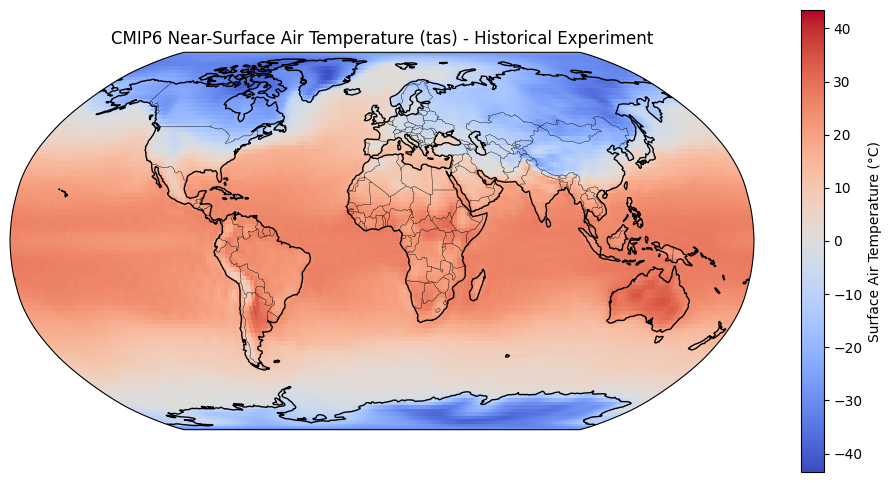

In [11]:
fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

tas_slice.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    cbar_kwargs={'label': 'Surface Air Temperature (°C)'}
)

plt.title("CMIP6 Near-Surface Air Temperature (tas) - Historical Experiment")
plt.show()

## Compute a Zonal Mean

A zonal mean (averaged over longitude) helps us see how temperature changes with latitude.

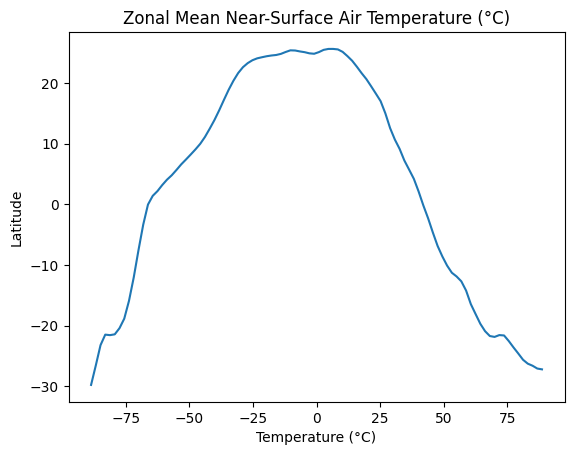

In [9]:
# Compute zonal mean (average over longitude)
if "lon" not in tas_slice.dims and "longitude" in tas_slice.dims:
    tas_slice = tas_slice.rename({"longitude": "lon"})

tas_zonal = tas_slice.mean(dim='lon')

tas_zonal.plot()
plt.title("Zonal Mean Near-Surface Air Temperature (°C)")
plt.ylabel("Latitude")
plt.xlabel("Temperature (°C)")
plt.show()
